# Import The Required Library

In [1]:
import sklearn
print(sklearn.__version__)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Other plots (example)

from src.exp import (
    ExperimentConfig, ExperimentFacade,
    DataReadConfig, PlotManager
)

1.8.0


## 1. Prioritise the Use of Scikit Learn Intelex Patch over Regular Scikit-learn Library

In [ ]:
ExperimentFacade.enable_intel_acceleration()

sklearnex not installed; using standard sklearn


## 2. Inform The Dataset Location

In [3]:
data_cfg = DataReadConfig(
    root_dir="Dataset/data",        # the root directory to search for CSV files
    recursive=True,                 # whether to search for files in subdirectories
    exclude_filenames=["cclass.csv", "unclean focus.csv","unclean cclass.csv","focus.csv"],  # the excluded files
    add_source_column=False,        # enable this to make additional column filled with the original taken filenames
)

## 3. Put the Configuration of Optuna

In [4]:
cfg = ExperimentConfig(
    outer_folds=5,              # number of outer folds for nested cross-validation
    inner_folds=5,              # number of inner folds for hyperparameter tuning
    n_trials=40,                # number of hyperparameter optimization trials
    seed=42,                    # random seed for reproducibility
    log_target=True             # whether to log-transform the target variable (if applicable)
)

## 4. List All the Regression Models

In [ ]:
# Define the list of models to evaluate
# Note: The actual implementation of these models should be defined in the ExperimentFacade or 
# imported from relevant libraries.

models = ["LinearRegression", "DecisionTree", "RandomForest", "BaggingSVR", "XGBoost", "NeuralNetwork", "FTTransformer"] # "SVR", "XGBoost", "NeuralNetwork"]

## 5. Initialize the experiment facade with the specified configurations and model list

In [6]:
exp = ExperimentFacade.from_folder(
    data_cfg=data_cfg,                      # configuration for reading the data
    target="price",                         # the target variable for prediction    
    cfg=cfg,                                # the experiment configuration
    model_names=models,                     # the list of model names to evaluate
    hparam_json="config/hyperparams.json"   # the path to the JSON file containing hyperparameter search spaces
)


[schema]
  numerical cols: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
  categorical cols: ['model', 'transmission', 'fuelType']
  target col: ['price']
  mapping: {'model': 'model', 'year': 'year', 'price': 'price', 'transmission': 'transmission', 'mileage': 'mileage', 'fuelType': 'fuelType', 'tax': 'tax', 'mpg': 'mpg', 'engineSize': 'engineSize'}


## 6. Run the experiment (this will perform nested cross-validation, hyperparameter tuning, and model evaluation)

In [7]:
# Run the experiment (this will perform nested cross-validation, hyperparameter tuning, and model evaluation)
# Dataset summary + correlation plot (saved to outputs/figures)
info = exp.data_info(out_dir="outputs/csvs", prefix="dataset")
print(info)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   model         99187 non-null  category
 1   year          99187 non-null  int64   
 2   price         99187 non-null  int64   
 3   transmission  99187 non-null  category
 4   mileage       99187 non-null  int64   
 5   fuelType      99187 non-null  category
 6   tax           99187 non-null  int64   
 7   mpg           99187 non-null  float64 
 8   engineSize    99187 non-null  float64 
dtypes: category(3), float64(2), int64(4)
memory usage: 4.9 MB
None


## 7. Generate and save the correlation heatmap

[saved] /Users/macbook/Library/CloudStorage/GoogleDrive-nur.ichsan@gmail.com/My Drive/UNS/2023/Business Intelligence/Paper/Salomo/NewIJAI/outputs/figures/correlation/correlation_heatmap.png
Saved correlation heatmap to: outputs/figures/correlation/correlation_heatmap.png


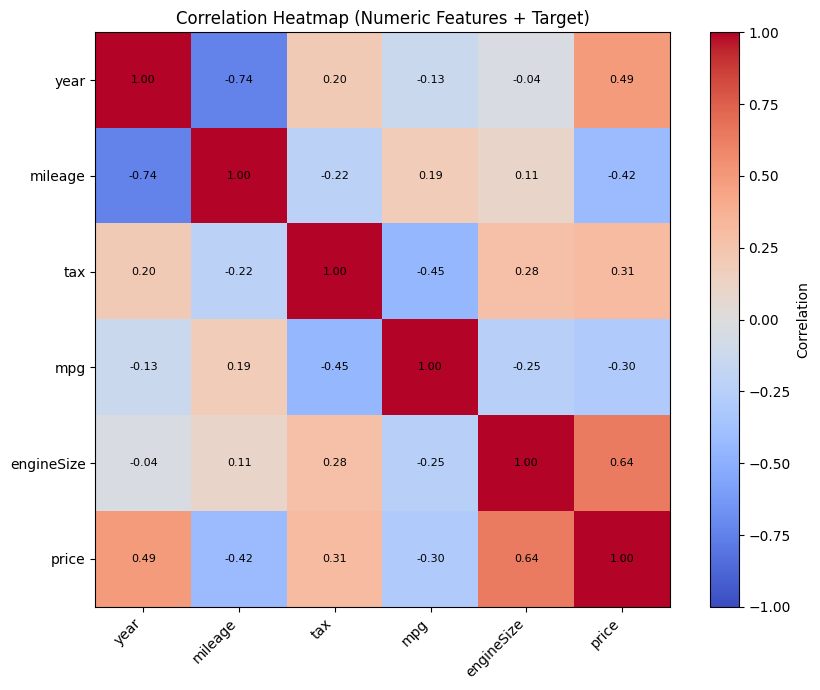

In [8]:
# Generate and save the correlation heatmap
corr_path = exp.correlation_plot(out_dir="outputs/figures/correlation", 
                                 filename="correlation_heatmap.png")

print(f"Saved correlation heatmap to: {corr_path}")

## 8. Run the experiment (this will perform nested cross-validation, hyperparameter tuning, and model evaluation)


In [9]:
results = exp.run()

[I 2026-05-16 07:20:34,733] A new study created in memory with name: LinearRegression_OuterFold_1_residual_cfg_base
[I 2026-05-16 07:20:37,628] Trial 0 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-05-16 07:20:39,388] Trial 1 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-05-16 07:20:41,022] Trial 2 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-05-16 07:20:42,613] Trial 3 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-05-16 07:20:44,361] Trial 4 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-05-16 07:20:46,022] Trial 5 finished with value: 1842.5249137136684 and parameters: {}. Best is trial 0 with value: 1842.5249137136684.
[I 2026-05-16 07:20:

KeyboardInterrupt: 

## 9. Save the results to a CSV file

In [ ]:
results.to_csv("outputs/csvs/experiment_results.csv", index=False)

## 10. Display the experiment summary (this will include performance metrics for each model and fold)

In [ ]:
display(exp.summary())

## 11. Access the model summary DataFrame

In [ ]:
model_summary = exp.summary()["model"]

## 12. Perform significance testing comparing all models against the baseline (e.g., "XGBoost+PseudoHuber")

In [ ]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    display(exp.significance(
        metric=metric,                              # the evaluation metric to compare (e.g., R2, MAE, RMSE)
        baseline="XGBoost+PseudoHuber",             # the baseline model to compare against (e.g., "XGBoost+PseudoHuber")
        models=model_summary.to_list()              # the list of models to include in the significance test (e.g., all models in the summary
    ))

### a. Display the significance results

In [ ]:
#display(sig)

### 13. Example of plotting the performance of models (e.g., R2 scores) using the PlotManager

In [ ]:
pm = PlotManager("outputs/figures/metrics")

### a. Generate and save point range plots for each metric

In [ ]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    is_ascending = metric != "R2" and metric != "NegMSE"
    fig = pm.plot_point_range(results_df=results, metric=metric, ascending=is_ascending)
    pm.save_fig(fig, f"point_range_{metric.lower()}")

### b. Display significance matrices for each metric

In [ ]:
for metric in ["R2", "MAE", "MedAE", "MSE", "RMSE"]:
    display(exp.significance_matrix(metric=metric))

## 14. Save the best hyperparameters for each model to a JSON file

In [ ]:
exp.save_best_params()

## 15. SHAP analysis

### a. Populate Shap Analyzer with the Model Summary

In [ ]:
shap_analyzer = exp.shap(models=model_summary)

### b. List all the Available Models

In [ ]:
shap_analyzer.available_models()

### c. Generate and save SHAP beeswarm plots for all models

In [ ]:
for m in shap_analyzer.available_models():
    shap_analyzer.beeswarm(m)